In [35]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [36]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [37]:
ts = pd.read_csv('/home/pmg2147/ModulAir NMF/OceanRoof/MOD-00068-raw.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','co2','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,co2,o3,no,no2,rh,temp
0,2025-06-02T19:59:38Z,3.029,0.201,0.077,0.034,0.047,0.030,3.906,265.418,418.720,41.858,4.566,38.885,40.8,22.3
1,2025-06-02T19:58:38Z,3.078,0.240,0.067,0.009,0.018,0.035,3.751,265.489,417.756,43.013,4.529,40.073,40.7,22.3
2,2025-06-02T19:57:38Z,3.182,0.204,0.079,0.026,0.040,0.013,3.441,270.415,416.792,42.160,4.550,38.178,40.7,22.3
3,2025-06-02T19:56:38Z,2.921,0.279,0.100,0.008,0.046,0.017,3.254,271.826,416.913,42.746,4.541,38.900,40.6,22.4
4,2025-06-02T19:55:38Z,2.925,0.274,0.087,0.013,0.018,0.026,3.472,266.900,417.154,42.462,4.544,38.190,40.6,22.4


In [38]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,co2,o3,no,no2,rh,temp
0,2025-06-02 19:59:38,3.029,0.201,0.077,0.034,0.047,0.030,3.906,265.418,418.720,41.858,4.566,38.885,40.8,22.3
1,2025-06-02 19:58:38,3.078,0.240,0.067,0.009,0.018,0.035,3.751,265.489,417.756,43.013,4.529,40.073,40.7,22.3
2,2025-06-02 19:57:38,3.182,0.204,0.079,0.026,0.040,0.013,3.441,270.415,416.792,42.160,4.550,38.178,40.7,22.3
3,2025-06-02 19:56:38,2.921,0.279,0.100,0.008,0.046,0.017,3.254,271.826,416.913,42.746,4.541,38.900,40.6,22.4
4,2025-06-02 19:55:38,2.925,0.274,0.087,0.013,0.018,0.026,3.472,266.900,417.154,42.462,4.544,38.190,40.6,22.4


## Full Timeseries Plot

In [39]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  co2 = ('co2','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,co2,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,,
2024-05-14,7.854776,0.769815,0.349458,0.102393,0.140719,0.099253,12.075363,456.028687,509.651656,17.672868,58.621488,8.238681,48.739715,25.329124
2024-05-15,13.722677,1.157640,0.276309,0.076761,0.101881,0.094672,6.554652,245.041902,508.075670,-21.168041,22.228797,15.355705,77.327514,18.619623
2024-05-16,2.291840,0.122617,0.061442,0.021607,0.034903,0.042295,2.106938,173.943268,487.952390,-27.471842,11.603025,13.816653,81.329583,17.312569
2024-05-17,4.194653,0.271647,0.139273,0.048851,0.071475,0.069108,4.627942,196.789544,465.086360,-5.462550,6.351692,12.637423,62.426806,21.012847
2024-05-18,6.328684,0.402917,0.176118,0.054521,0.072299,0.058600,6.002683,253.453182,460.883476,-6.549874,4.901106,13.086419,61.014028,20.754028


In [40]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,co2,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,,
2024-05-14,7.854776,0.769815,0.349458,0.102393,0.140719,0.099253,12.075363,456.028687,509.651656,17.672868,58.621488,8.238681,48.739715,25.329124,9.928681
2024-05-15,13.722677,1.157640,0.276309,0.076761,0.101881,0.094672,6.554652,245.041902,508.075670,-21.168041,22.228797,15.355705,77.327514,18.619623,4.935460
2024-05-16,2.291840,0.122617,0.061442,0.021607,0.034903,0.042295,2.106938,173.943268,487.952390,-27.471842,11.603025,13.816653,81.329583,17.312569,2.093986
2024-05-17,4.194653,0.271647,0.139273,0.048851,0.071475,0.069108,4.627942,196.789544,465.086360,-5.462550,6.351692,12.637423,62.426806,21.012847,4.693534
2024-05-18,6.328684,0.402917,0.176118,0.054521,0.072299,0.058600,6.002683,253.453182,460.883476,-6.549874,4.901106,13.086419,61.014028,20.754028,5.533668


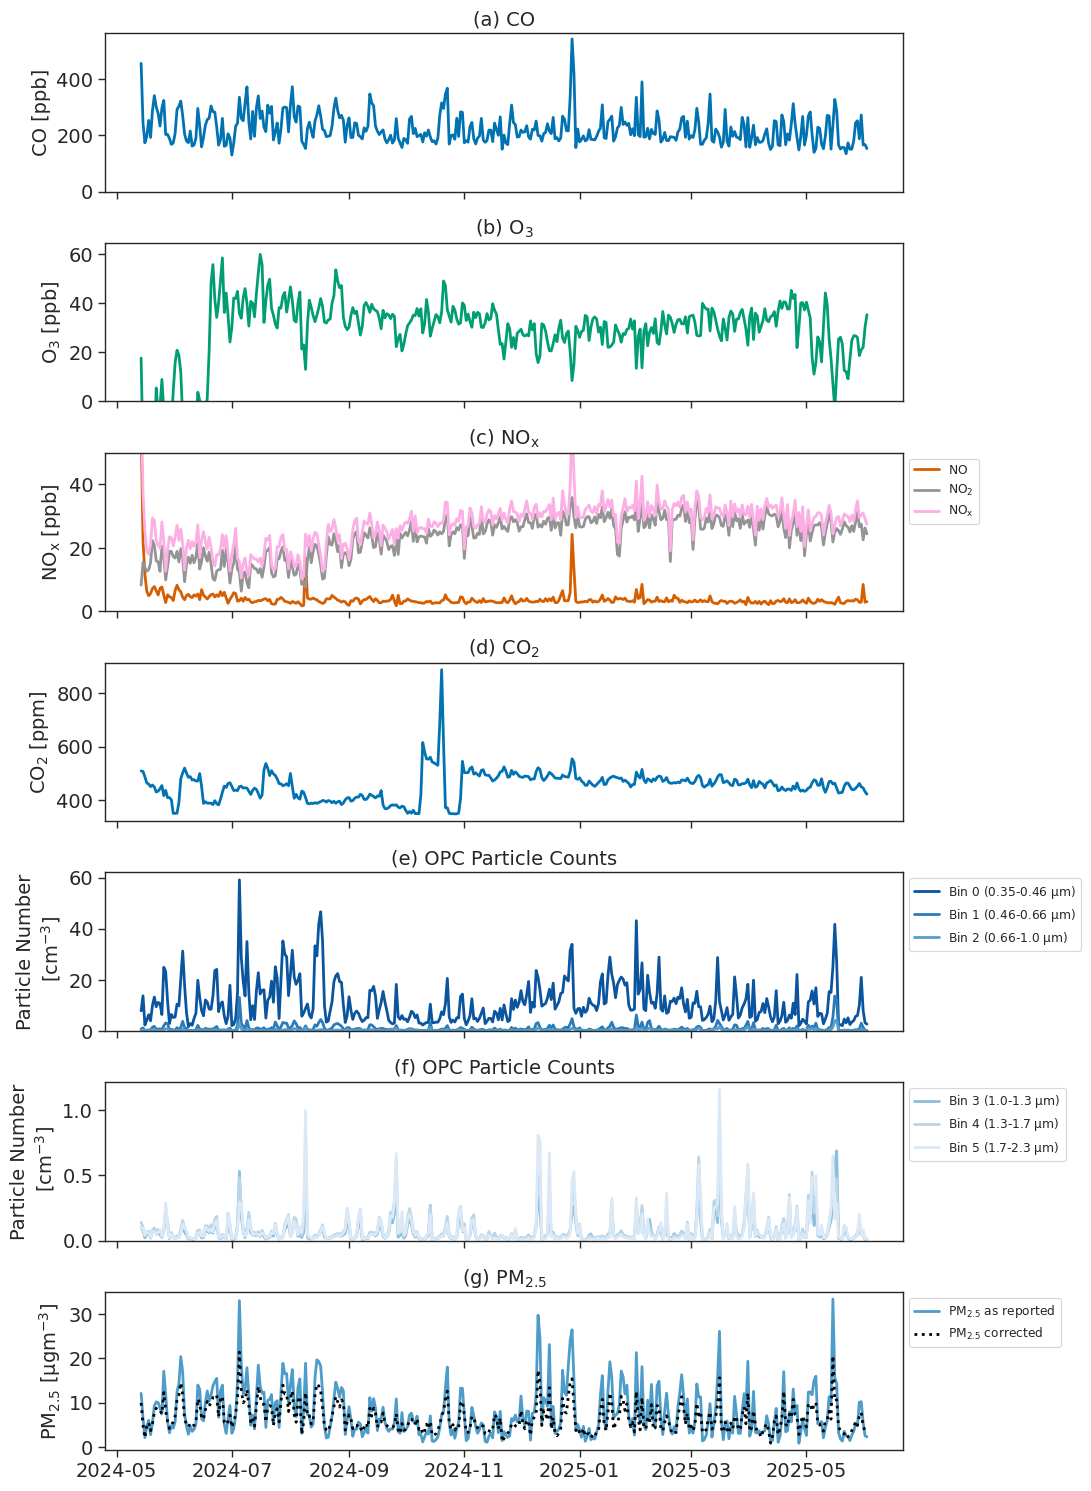

In [41]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=7, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 3rd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


#plot co2 on the 4th row
ax[3].plot(ts_day['co2'], lw=2, label="$CO_2$", color=sns.color_palette()[0])
ax[3].set_ylabel("$CO_2$ [ppm]", fontsize=14)


# plot the OPC bins on the 5th and 6th rows
ax[4].plot(ts_day['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[4].plot(ts_day['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[4].plot(ts_day['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


ax[5].plot(ts_day['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[5].plot(ts_day['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[5].plot(ts_day['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[5].set(ylim=(0, None))
ax[5].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[5].legend(fontsize = 14)


#plot pm25 on the 7th row
ax[6].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[6].plot(ts_day['pm25_c'], lw=2, label="$PM_{2.5}$ corrected", color='black',linestyle='dotted')
ax[6].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)
ax[6].legend(fontsize = 14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) $CO_2$", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) OPC Particle Counts", fontsize=14)
ax[6].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[6].tick_params(axis='both', which='major', labelsize=14)
ax[6].locator_params(axis='y', nbins=4)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[5], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[6], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

#fig.savefig('/home/pmg2147/ModulAir NMF/OceanRoof/timeseries_MOD-00068.png')

## Dirunal Plots

In [42]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  co2 = ('co2','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,co2,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,,
2024-05-14 15:00:00,10.455227,0.894114,0.344636,0.093614,0.121773,0.073659,11.468795,NaN,513.715364,NaN,NaN,NaN,43.659091,26.645455
2024-05-14 16:00:00,9.174000,0.841484,0.336194,0.089613,0.116677,0.077516,11.990903,NaN,528.608548,NaN,NaN,NaN,43.958065,26.387097
2024-05-14 17:00:00,6.329967,0.645017,0.281450,0.077717,0.105083,0.073567,10.446433,415.304000,515.929017,23.680067,NaN,7.2260,47.955000,24.846667
2024-05-14 18:00:00,7.439267,0.728533,0.349883,0.100867,0.149233,0.098967,12.065533,479.335083,503.844317,27.679817,NaN,4.4464,44.196667,26.988333
2024-05-14 19:00:00,10.764964,0.954732,0.393500,0.110946,0.156357,0.103179,15.740375,518.237000,500.555768,30.421000,NaN,1.8380,43.175000,27.637500


In [43]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,co2,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,,
2024-05-14 15:00:00,10.455227,0.894114,0.344636,0.093614,0.121773,0.073659,11.468795,NaN,513.715364,NaN,NaN,NaN,43.659091,26.645455,7.908792
2024-05-14 16:00:00,9.174000,0.841484,0.336194,0.089613,0.116677,0.077516,11.990903,NaN,528.608548,NaN,NaN,NaN,43.958065,26.387097,8.058638
2024-05-14 17:00:00,6.329967,0.645017,0.281450,0.077717,0.105083,0.073567,10.446433,415.304000,515.929017,23.680067,NaN,7.2260,47.955000,24.846667,7.617290
2024-05-14 18:00:00,7.439267,0.728533,0.349883,0.100867,0.149233,0.098967,12.065533,479.335083,503.844317,27.679817,NaN,4.4464,44.196667,26.988333,8.116666
2024-05-14 19:00:00,10.764964,0.954732,0.393500,0.110946,0.156357,0.103179,15.740375,518.237000,500.555768,30.421000,NaN,1.8380,43.175000,27.637500,9.219707


In [44]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,co2,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,,
2024-05-14 15:00:00,10.455227,0.894114,0.344636,0.093614,0.121773,0.073659,11.468795,NaN,513.715364,NaN,NaN,NaN,43.659091,26.645455,7.908792,15
2024-05-14 16:00:00,9.174000,0.841484,0.336194,0.089613,0.116677,0.077516,11.990903,NaN,528.608548,NaN,NaN,NaN,43.958065,26.387097,8.058638,16
2024-05-14 17:00:00,6.329967,0.645017,0.281450,0.077717,0.105083,0.073567,10.446433,415.304000,515.929017,23.680067,NaN,7.2260,47.955000,24.846667,7.617290,17
2024-05-14 18:00:00,7.439267,0.728533,0.349883,0.100867,0.149233,0.098967,12.065533,479.335083,503.844317,27.679817,NaN,4.4464,44.196667,26.988333,8.116666,18
2024-05-14 19:00:00,10.764964,0.954732,0.393500,0.110946,0.156357,0.103179,15.740375,518.237000,500.555768,30.421000,NaN,1.8380,43.175000,27.637500,9.219707,19


In [45]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,co2,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,,
00:00,12.676167,1.384117,0.364909,0.078524,0.099388,0.096127,8.213732,244.940659,462.135264,26.011086,3.042216,26.299342,61.835411,13.315318,6.708508
01:00,12.755505,1.382016,0.375175,0.080648,0.100332,0.099062,8.257053,235.778793,463.396747,25.030919,2.990843,25.871611,63.031281,12.983139,6.733510
02:00,12.998581,1.421017,0.406342,0.088902,0.109048,0.110707,8.532507,229.435930,464.936193,23.989787,3.047514,25.717308,64.417228,12.661981,6.832800
03:00,13.519406,1.506070,0.421782,0.092906,0.112911,0.116059,8.645959,222.195713,466.288997,23.005377,2.954223,25.258277,65.479383,12.323672,6.875185
04:00,13.860929,1.524716,0.417791,0.091241,0.111474,0.116106,8.425254,216.016271,467.805472,22.138323,2.993371,25.063940,66.590677,12.063697,6.823087
05:00,14.230874,1.564901,0.410494,0.087637,0.108042,0.112988,8.217762,214.439607,469.430278,21.282988,3.020677,25.182655,67.551378,11.834722,6.772862
06:00,13.945763,1.455361,0.384989,0.085897,0.112171,0.122563,8.289754,216.562036,470.196937,20.541286,2.996133,24.804713,67.987508,11.758490,6.800971
07:00,13.586842,1.337433,0.361163,0.083124,0.110635,0.121512,8.374024,219.974945,469.805513,20.196476,3.037716,24.343828,67.413326,12.055937,6.827176
08:00,12.814714,1.194626,0.327956,0.076694,0.104786,0.111549,8.235608,224.629720,468.320028,21.046627,3.434000,23.081888,64.817303,12.927794,6.767216


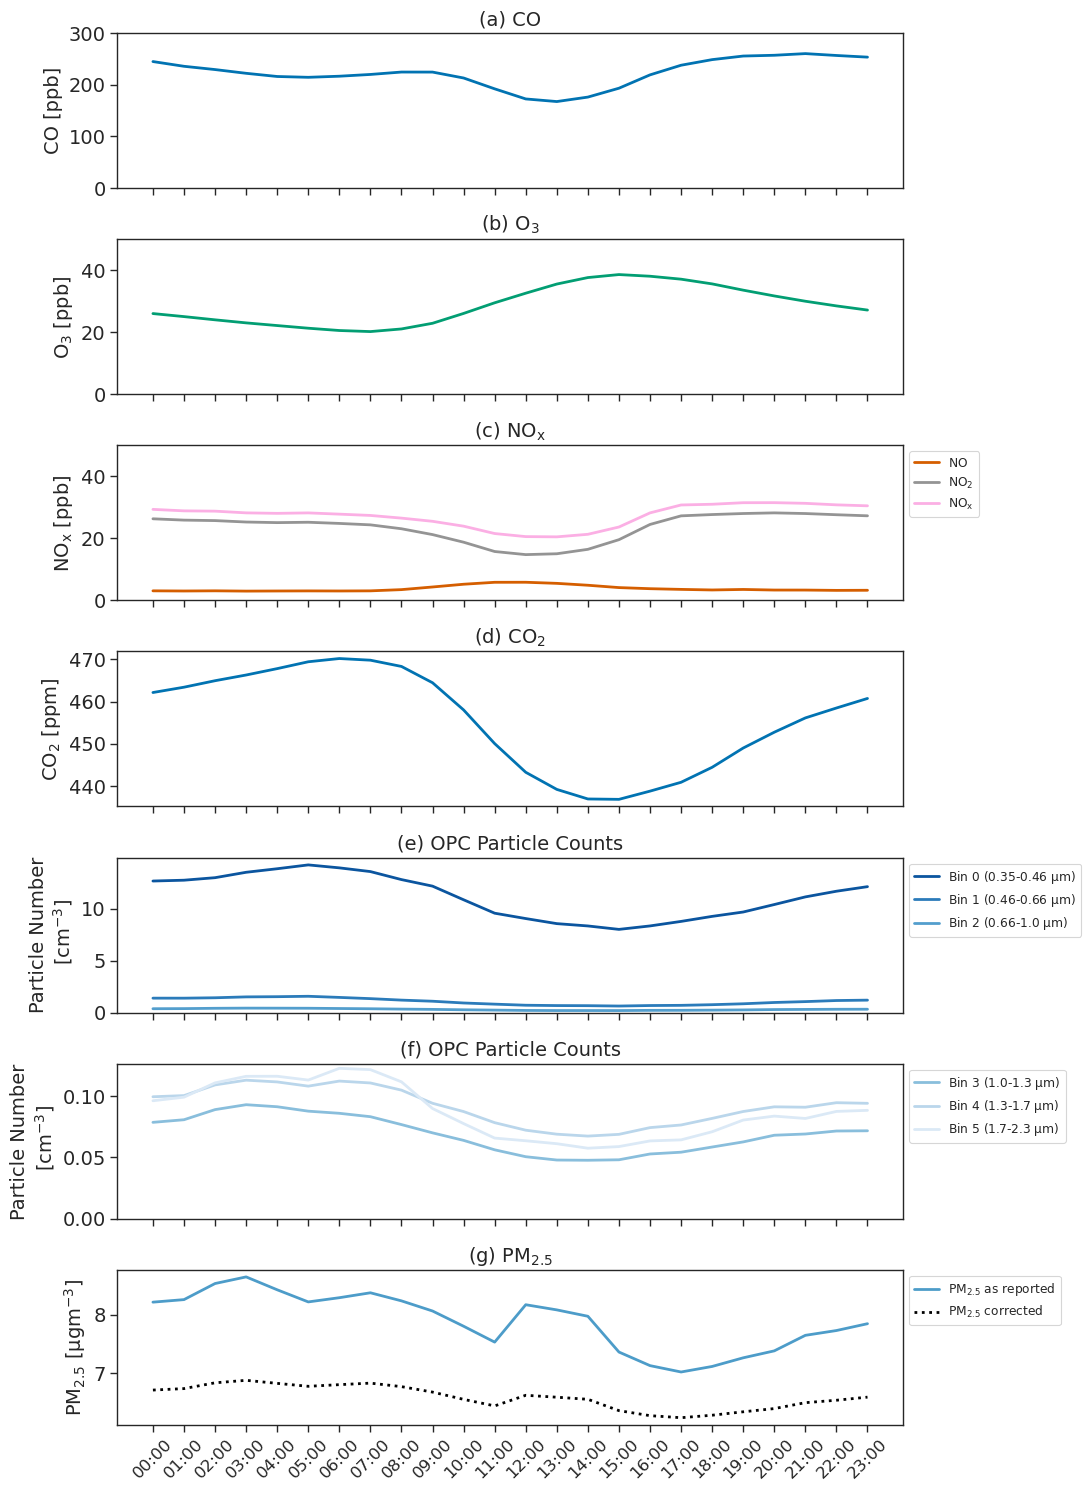

In [46]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=7, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, 300)

# plot the o3 on the second axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, 50)

#plot nox on the 3rd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


#plot co2 on the 4th row
ax[3].plot(diurnal_data['co2'], lw=2, label="$CO_2$", color=sns.color_palette()[0])
ax[3].set_ylabel("$CO_2$ [ppm]", fontsize=14)


# plot the OPC bins on the 5th and 6th rows
ax[4].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[4].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[4].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


ax[5].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[5].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[5].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[5].set(ylim=(0, None))
ax[5].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[5].legend(fontsize = 14)


#plot pm25 on the 7th row
ax[6].plot(diurnal_data['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[6].plot(diurnal_data['pm25_c'], lw=2, label="$PM_{2.5}$ corrected", color='black',linestyle='dotted')
ax[6].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)
ax[6].legend(fontsize = 14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) $CO_2$", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) OPC Particle Counts", fontsize=14)
ax[6].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[6].tick_params(axis='both', which='major', labelsize=14)
ax[6].locator_params(axis='y', nbins=4)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[5], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[6], "upper left", bbox_to_anchor=(1, 1))


plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

#fig.savefig('/home/pmg2147/ModulAir NMF/OceanRoof/dirunal_MOD-00068_allfeatures.png')

## Diurnal by Season

In [47]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [48]:
ts_hour = ts_hour.reset_index()

In [49]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,co2,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2024-05-14 15:00:00,10.455227,0.894114,0.344636,0.093614,0.121773,0.073659,11.468795,NaN,513.715364,NaN,NaN,NaN,43.659091,26.645455,7.908792,15,Spring
1,2024-05-14 16:00:00,9.174000,0.841484,0.336194,0.089613,0.116677,0.077516,11.990903,NaN,528.608548,NaN,NaN,NaN,43.958065,26.387097,8.058638,16,Spring
2,2024-05-14 17:00:00,6.329967,0.645017,0.281450,0.077717,0.105083,0.073567,10.446433,415.304000,515.929017,23.680067,NaN,7.2260,47.955000,24.846667,7.617290,17,Spring
3,2024-05-14 18:00:00,7.439267,0.728533,0.349883,0.100867,0.149233,0.098967,12.065533,479.335083,503.844317,27.679817,NaN,4.4464,44.196667,26.988333,8.116666,18,Spring
4,2024-05-14 19:00:00,10.764964,0.954732,0.393500,0.110946,0.156357,0.103179,15.740375,518.237000,500.555768,30.421000,NaN,1.8380,43.175000,27.637500,9.219707,19,Spring


In [50]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      7.883563  0.659822  0.217389  0.059106  0.084453  0.078487   
       1      7.535454  0.610042  0.206981  0.057912  0.082669  0.077897   
       2      7.864419  0.661041  0.219627  0.060233  0.085099  0.080689   
       3      8.126651  0.727880  0.234785  0.062531  0.088501  0.084612   
       4      8.482860  0.797553  0.258496  0.068863  0.096155  0.096822   
...                ...       ...       ...       ...       ...       ...   
Winter 19    13.556602  1.083112  0.271291  0.057282  0.074102  0.084344   
       20    14.302489  1.317048  0.342112  0.067604  0.078351  0.083204   
       21    15.062326  1.387283  0.347792  0.065342  0.070194  0.061276   
       22    15.543964  1.458991  0.351264  0.066320  0.072028  0.061461   
       23    15.645144  1.381078  0.341991  0.066864  0.074335  0.070329   

                 pm25          co         co2         o3        no        no2  \
Season Hour                                                                     
Autumn 0     5.500161  250.240357  459.250708  30.702264  2.638089  27.827308   
       1     5.253166  237.798695  459.912576  30.216784  2.735222  27.511551   
       2     5.197714  229.212118  461.211553  29.728906  2.691289  27.042835   
       3     5.180204  222.646829  462.767239  28.947144  2.654141  27.027357   
       4     5.425817  214.263700  464.105715  28.251659  2.652610  26.417784   
...               ...         ...         ...        ...       ...        ...   
Winter 19    8.480191  232.900522  479.434116  28.076991  3.100743  30.649579   
       20    8.822828  229.759364  479.445299  27.705878  3.050759  30.447359   
       21    9.294861  234.281053  480.949276  27.108210  3.446702  30.447804   
       22    8.729415  235.947840  481.902400  26.842705  3.745131  30.420925   
       23    9.177560  237.749548  482.863005  26.490124  4.208833  30.405107   

                    rh       temp    pm25_c  
Season Hour                                  
Autumn 0     62.193297  14.809011  5.983138  
       1     63.253197  14.464034  5.917722  
       2     64.655255  14.103502  5.916820  
       3     65.949669  13.821414  5.928564  
       4     67.183040  13.609615  6.020767  
...                ...        ...       ...  
Winter 19    52.240704   2.621407  6.022944  
       20    53.197463   2.327222  6.133303  
       21    54.103441   2.026236  6.280663  
       22    55.086619   1.724290  6.120659  
       23    56.092907   1.450574  6.264671  

[96 rows x 15 columns]

In [51]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,co2,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,7.883563,0.659822,0.217389,0.059106,0.084453,0.078487,5.500161,250.240357,459.250708,30.702264,2.638089,27.827308,62.193297,14.809011,5.983138
1,Autumn,1,7.535454,0.610042,0.206981,0.057912,0.082669,0.077897,5.253166,237.798695,459.912576,30.216784,2.735222,27.511551,63.253197,14.464034,5.917722
2,Autumn,2,7.864419,0.661041,0.219627,0.060233,0.085099,0.080689,5.197714,229.212118,461.211553,29.728906,2.691289,27.042835,64.655255,14.103502,5.916820
3,Autumn,3,8.126651,0.727880,0.234785,0.062531,0.088501,0.084612,5.180204,222.646829,462.767239,28.947144,2.654141,27.027357,65.949669,13.821414,5.928564
4,Autumn,4,8.482860,0.797553,0.258496,0.068863,0.096155,0.096822,5.425817,214.263700,464.105715,28.251659,2.652610,26.417784,67.183040,13.609615,6.020767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,13.556602,1.083112,0.271291,0.057282,0.074102,0.084344,8.480191,232.900522,479.434116,28.076991,3.100743,30.649579,52.240704,2.621407,6.022944
92,Winter,20,14.302489,1.317048,0.342112,0.067604,0.078351,0.083204,8.822828,229.759364,479.445299,27.705878,3.050759,30.447359,53.197463,2.327222,6.133303
93,Winter,21,15.062326,1.387283,0.347792,0.065342,0.070194,0.061276,9.294861,234.281053,480.949276,27.108210,3.446702,30.447804,54.103441,2.026236,6.280663
94,Winter,22,15.543964,1.458991,0.351264,0.066320,0.072028,0.061461,8.729415,235.947840,481.902400,26.842705,3.745131,30.420925,55.086619,1.724290,6.120659


In [52]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [53]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,co2,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,7.883563,0.659822,0.217389,0.059106,0.084453,0.078487,5.500161,250.240357,459.250708,30.702264,2.638089,27.827308,62.193297,14.809011,5.983138
01:00,Autumn,1,7.535454,0.610042,0.206981,0.057912,0.082669,0.077897,5.253166,237.798695,459.912576,30.216784,2.735222,27.511551,63.253197,14.464034,5.917722
02:00,Autumn,2,7.864419,0.661041,0.219627,0.060233,0.085099,0.080689,5.197714,229.212118,461.211553,29.728906,2.691289,27.042835,64.655255,14.103502,5.916820
03:00,Autumn,3,8.126651,0.727880,0.234785,0.062531,0.088501,0.084612,5.180204,222.646829,462.767239,28.947144,2.654141,27.027357,65.949669,13.821414,5.928564
04:00,Autumn,4,8.482860,0.797553,0.258496,0.068863,0.096155,0.096822,5.425817,214.263700,464.105715,28.251659,2.652610,26.417784,67.183040,13.609615,6.020767
05:00,Autumn,5,8.747307,0.857321,0.281496,0.072757,0.099323,0.103653,5.666311,212.113447,465.823071,27.521506,2.622238,26.103296,68.360128,13.371593,6.108783
06:00,Autumn,6,8.660795,0.845392,0.282718,0.072309,0.095717,0.094254,5.226421,210.196341,467.006761,26.905993,2.594760,26.122124,69.319587,13.144459,5.989366
07:00,Autumn,7,8.746564,0.877227,0.288247,0.071503,0.093627,0.090112,5.149673,213.240400,467.321682,26.573525,2.538419,25.891674,69.677015,13.223718,5.979037
08:00,Autumn,8,8.354612,0.842851,0.277352,0.069172,0.093293,0.090833,5.470234,222.051571,467.201432,26.710636,2.638695,24.264666,67.588846,13.968040,6.061664
09:00,Autumn,9,7.791178,0.828225,0.280510,0.066524,0.089023,0.080028,5.324394,219.950775,464.295448,28.127014,3.001284,21.408269,62.560851,15.320445,5.965152


In [54]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

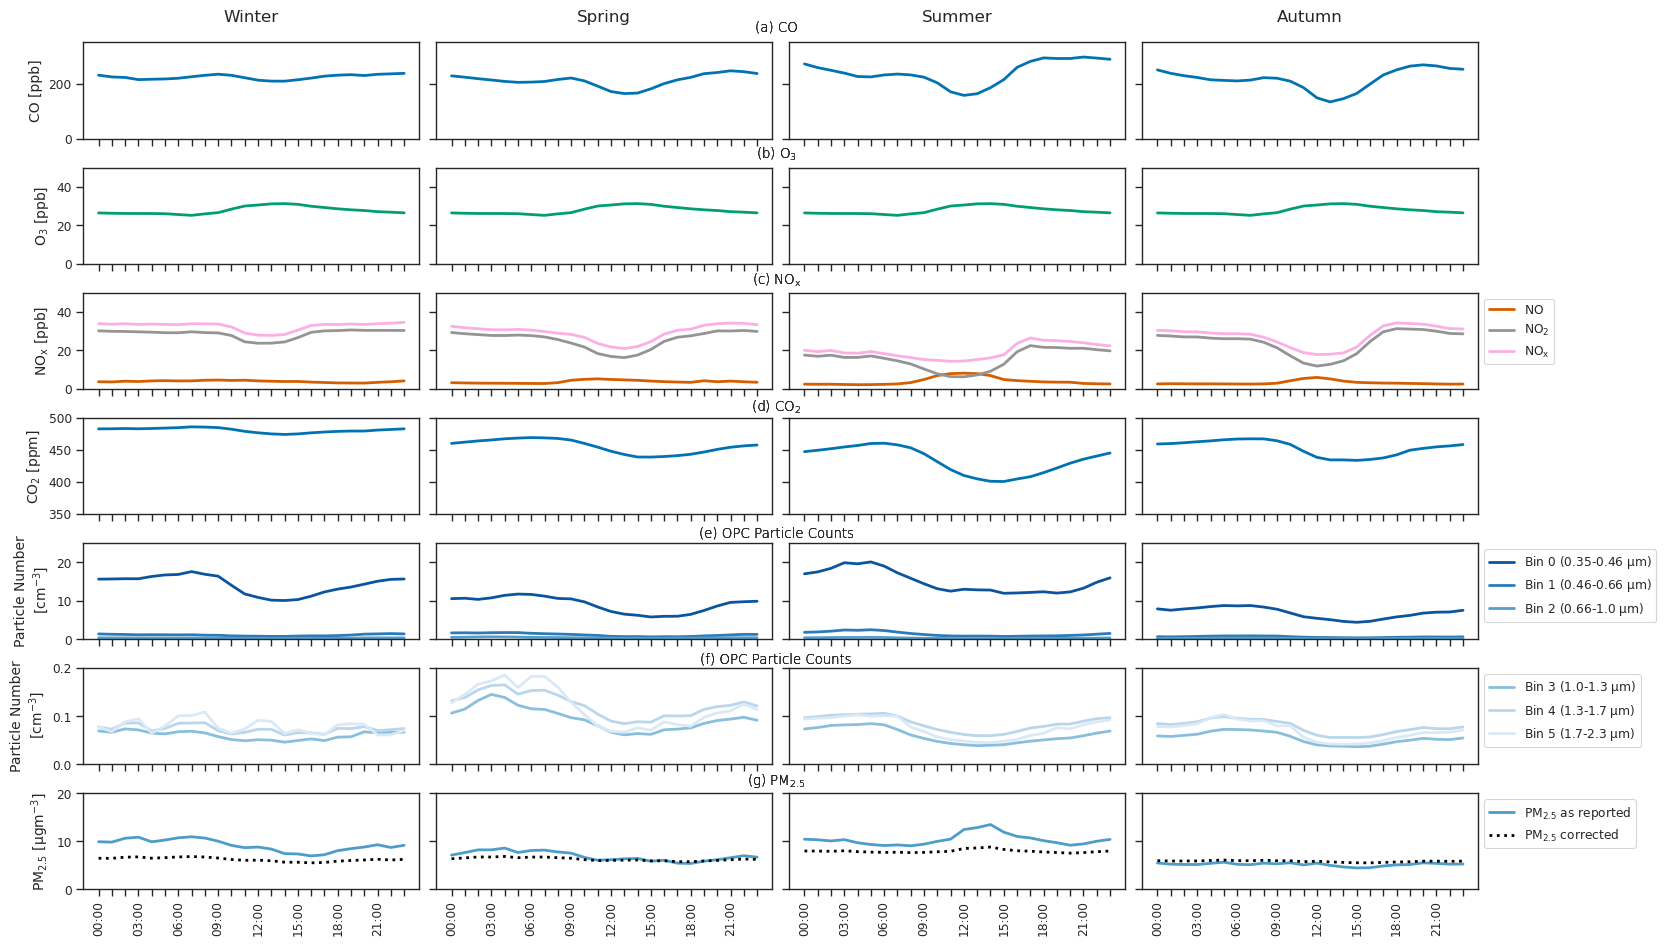

In [201]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=7, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)
    
    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(0, 350)
    ax[0,i].set_xticks(range(0, 24))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))
    
    #plot co2 on the 4th row
    ax[3,0].set_ylabel("$CO_2$ [ppm]", fontsize=10)
    ax[3,i].plot(seasons_order[i]['co2'], lw=2, label="$CO_2$", color=sns.color_palette()[0])
    ax[3,i].set_ylim(350, 500)

    # plot the OPC bins on the 5th and 6th rows
    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[4,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[4,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[4,i].set(ylim=(0, 25))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    ax[5,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[5,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[5,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[5,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[5,i].set(ylim=(0, 0.20))
    ax[5,3].legend(fontsize = 14)
    sns.move_legend(ax[5,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 7th row
    ax[6,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[6,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[6,i].plot(seasons_order[i]['pm25_c'], lw=2, label="$PM_{2.5}$ corrected", color='black',linestyle='dotted')
    ax[6,i].set(ylim=(0, 20))
    ax[6,3].legend(fontsize = 14)
    sns.move_legend(ax[6,3], "upper left", bbox_to_anchor=(1, 1))
    ax[6,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(7):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    fig.text(0.51, 0.89, "(a) CO", weight = 'light', ha = 'center')
    fig.text(0.51, 0.775, "(b) $O_3$", weight = 'light', ha = 'center')
    fig.text(0.51, 0.66, "(c) $NO_x$", weight = 'light', ha = 'center')
    fig.text(0.51, 0.545, "(d) $CO_2$", weight = 'light', ha = 'center')
    fig.text(0.51, 0.4305, "(e) OPC Particle Counts", weight = 'light', ha = 'center')
    fig.text(0.51, 0.3155, "(f) OPC Particle Counts", weight = 'light', ha = 'center')
    fig.text(0.51, 0.205, "(g) $PM_{2.5}$", weight = 'light', ha = 'center')

#fig.savefig('/home/pmg2147/ModulAir NMF/OceanRoof/diurnal_by_season_MOD-00068.png')